# CIS6005 Computational Intelligence
## Notebook 05 — Feature Engineering
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### What Is Feature Engineering?
Feature engineering is the process of creating **new, more informative features** from existing ones.

**Why does it matter?** Raw data is rarely in its most useful form for a model. A well-engineered feature can provide a model with insights it could not derive on its own — directly improving predictive accuracy.

Think of it as giving the model **expert knowledge** baked into the data itself.

> A model trained on raw features scores 80%. The same model trained on well-engineered features can score 87%+. Feature engineering is often the biggest performance lever in a competition.

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA     = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA    = PROJECT_ROOT / 'data' / 'processed'

# Load raw train data for comparison in Section 8
train_raw = pd.read_csv(RAW_DATA / 'train.csv')

# Load cleaned data from Phase 4
train_df = pd.read_csv(PROC_DATA / 'train_cleaned.csv')
test_df  = pd.read_csv(PROC_DATA / 'test_cleaned.csv')

print('✅ Loaded cleaned data')


✅ Loaded cleaned data


## 1. Health Score (Composite Feature)

**Why:** Instead of feeding the model 8 separate health metrics, we combine them into a single **composite health score** that summarises overall health behaviour. This helps the model by pre-digesting complex relationships.

**Design logic:**
- Higher exercise → better health → positive weight
- Higher BMI → worse health → negative weight
- More sleep → better health → positive weight
- Higher stress → worse health → negative weight

In [2]:
# ============================================================
# SECTION 1: Composite Health Score
# ============================================================

def add_health_score(df):
    """
    Create a composite health score combining multiple health metrics.
    Normalised per column to keep contributions balanced.
    """
    df = df.copy()
    
    # Helper: min-max normalise a column to [0, 1]
    def minmax(col):
        return (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-8)
    
    # Positive health contributors (higher = healthier)
    positive_features = ['exercise_duration', 'sleep_duration', 'step_count',
                         'water_intake', 'calorie_expenditure']
    # Negative health contributors (higher = less healthy)
    negative_features = ['bmi', 'heart_rate']

    pos_score = sum(minmax(f) for f in positive_features if f in df.columns)
    neg_score = sum(minmax(f) for f in negative_features if f in df.columns)

    df['health_score'] = pos_score - neg_score
    return df

train_df = add_health_score(train_df)
test_df  = add_health_score(test_df)

print('✅ health_score created')
print(f'   Train health_score range: [{train_df["health_score"].min():.2f}, {train_df["health_score"].max():.2f}]')
print(f'   Train health_score mean : {train_df["health_score"].mean():.2f}')

✅ health_score created
   Train health_score range: [-0.85, 3.57]
   Train health_score mean : 1.53


## 2. Activity Efficiency Ratio

**Why:** Calorie burn per minute of exercise tells us how intensely a student exercises. A student burning 400 calories in 30 minutes is far more active than one burning 400 calories in 90 minutes.

In [3]:
# ============================================================
# SECTION 2: Activity Efficiency Ratio
# ============================================================

def add_activity_efficiency(df):
    """Calorie burn per minute of exercise — measures exercise intensity."""
    df = df.copy()
    if 'calorie_expenditure' in df.columns and 'exercise_duration' in df.columns:
        # Avoid division by zero
        df['activity_efficiency'] = df['calorie_expenditure'] / (df['exercise_duration'] + 1)
    return df

train_df = add_activity_efficiency(train_df)
test_df  = add_activity_efficiency(test_df)

print('✅ activity_efficiency created (calories per exercise minute)')

✅ activity_efficiency created (calories per exercise minute)


## 3. Steps Per Calorie (Movement Efficiency)

**Why:** High step count with low calorie burn suggests slow walking. This ratio captures movement quality.

In [4]:
# ============================================================
# SECTION 3: Steps Per Calorie
# ============================================================

def add_steps_per_calorie(df):
    """Step count normalised by calorie expenditure — movement quality metric."""
    df = df.copy()
    if 'step_count' in df.columns and 'calorie_expenditure' in df.columns:
        df['steps_per_calorie'] = df['step_count'] / (df['calorie_expenditure'] + 1)
    return df

train_df = add_steps_per_calorie(train_df)
test_df  = add_steps_per_calorie(test_df)

print('✅ steps_per_calorie created')

✅ steps_per_calorie created


## 4. Sleep Quality Score

**Why:** Combining sleep duration and sleep quality into one score captures both dimensions of sleep health.

In [5]:
# ============================================================
# SECTION 4: Sleep Quality Score
# ============================================================

def add_sleep_score(df):
    """Combined sleep health score from duration and quality."""
    df = df.copy()
    if 'sleep_duration' in df.columns and 'sleep_quality' in df.columns:
        # map sleep quality to numeric values
        sleep_q_map = {'poor': 1, 'average': 2, 'good': 3, 'excellent': 4}
        sleep_num = df['sleep_quality'].map(sleep_q_map).fillna(2)
        df['sleep_score'] = df['sleep_duration'] * sleep_num
    elif 'sleep_duration' in df.columns:
        df['sleep_score'] = df['sleep_duration']
    return df

train_df = add_sleep_score(train_df)
test_df  = add_sleep_score(test_df)

print('✅ sleep_score created')


✅ sleep_score created


## 5. BMI Category (Domain Knowledge)

**Why:** The World Health Organisation (WHO) defines BMI categories that are clinically meaningful:
- Underweight: BMI < 18.5
- Normal: 18.5 ≤ BMI < 25
- Overweight: 25 ≤ BMI < 30
- Obese: BMI ≥ 30

Converting continuous BMI to a category adds domain knowledge that the model can leverage.

In [6]:
# ============================================================
# SECTION 5: BMI Category (WHO Standards)
# ============================================================

def add_bmi_category(df):
    """Categorise BMI into WHO clinical categories."""
    df = df.copy()
    if 'bmi' in df.columns:
        df['bmi_category'] = pd.cut(
            df['bmi'],
            bins=[-np.inf, 18.5, 25, 30, np.inf],
            labels=['underweight', 'normal', 'overweight', 'obese']
        ).astype(str)
    return df

train_df = add_bmi_category(train_df)
test_df  = add_bmi_category(test_df)

print('✅ bmi_category created')
print(f'   Distribution: {train_df["bmi_category"].value_counts().to_dict()}')

✅ bmi_category created
   Distribution: {'normal': 525945, 'overweight': 138368, 'underweight': 24070, 'obese': 1705}


## 6. Stress-Sleep Interaction

**Why:** High stress AND low sleep often occur together and compound each other's negative effects. Their interaction may be more predictive than either alone.

In [7]:
# ============================================================
# SECTION 6: Stress-Sleep Interaction Feature
# ============================================================

def add_stress_sleep_interaction(df):
    """Interaction term between stress and inverse sleep."""
    df = df.copy()
    if 'stress_level' in df.columns and 'sleep_duration' in df.columns:
        stress_map = {'low': 1, 'medium': 2, 'high': 3}
        stress_num = df['stress_level'].map(stress_map).fillna(2)
        df['stress_sleep_ratio'] = stress_num / (df['sleep_duration'] + 1)
    return df

train_df = add_stress_sleep_interaction(train_df)
test_df  = add_stress_sleep_interaction(test_df)

print('✅ stress_sleep_ratio created')


✅ stress_sleep_ratio created


## 7. Visualise Engineered Features vs Target

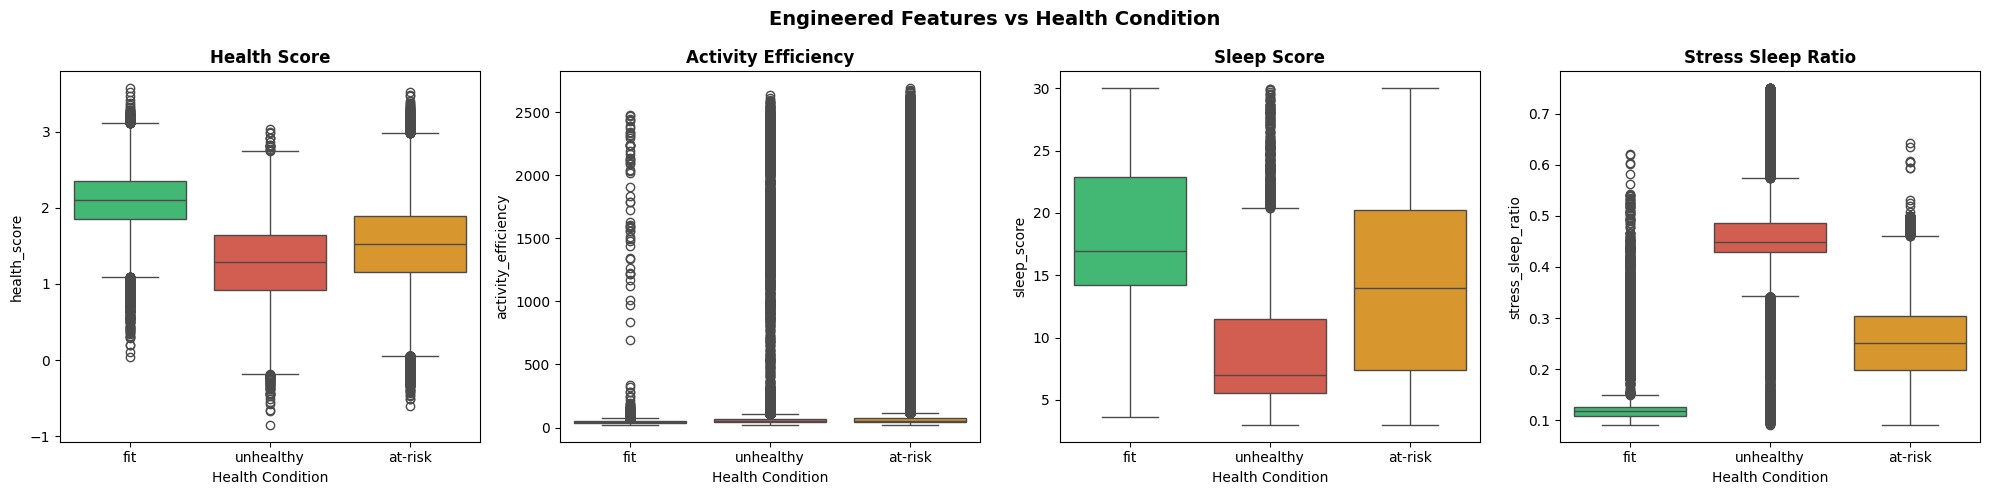


📊 INTERPRETATION:
   If boxes are clearly separated across classes, the feature is valuable.
   health_score should show the clearest separation.


In [8]:
# ============================================================
# SECTION 7: Visualise New Features vs Target
# ============================================================

new_features = ['health_score', 'activity_efficiency', 'sleep_score', 'stress_sleep_ratio']
existing_new_features = [f for f in new_features if f in train_df.columns]

PALETTE = {'fit': '#2ecc71', 'unhealthy': '#e74c3c', 'at-risk': '#f39c12'}
class_order = ['fit', 'unhealthy', 'at-risk']

fig, axes = plt.subplots(1, len(existing_new_features), figsize=(5 * len(existing_new_features), 5))
fig.suptitle('Engineered Features vs Health Condition', fontsize=14, fontweight='bold')

if len(existing_new_features) == 1:
    axes = [axes]

for i, feat in enumerate(existing_new_features):
    sns.boxplot(
        data=train_df, x='health_condition', y=feat,
        palette=PALETTE, order=class_order, ax=axes[i]
    )
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Health Condition')

plt.tight_layout()
plt.savefig(PROC_DATA / 'fe_01_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   If boxes are clearly separated across classes, the feature is valuable.')
print('   health_score should show the clearest separation.')

## 8. Summary of All Features

In [9]:
# ============================================================
# SECTION 8: Save Feature-Engineered Data
# ============================================================

train_df.to_csv(PROC_DATA / 'train_featured.csv', index=False)
test_df.to_csv(PROC_DATA  / 'test_featured.csv',  index=False)

original_features = [c for c in train_raw.columns if c not in ['id', 'health_condition']]
new_feat_list = [c for c in train_df.columns if c not in train_raw.columns]

print('=' * 65)
print('  PHASE 5 COMPLETE — Feature Engineering')
print('=' * 65)
print(f'  Original features  : {len(original_features)}')
print(f'  New features added : {len(new_feat_list)}')
print(f'  New features       : {new_feat_list}')
print(f'  Total features     : {train_df.shape[1] - 2}  (excl. id & target)')
print('=' * 65)
print(f'  ✅ Saved: data/processed/train_featured.csv')
print(f'  ✅ Saved: data/processed/test_featured.csv')
print('=' * 65)
print('  ✅ Ready for Phase 6: Data Preprocessing (Encoding + Scaling)')
print('=' * 65)

  PHASE 5 COMPLETE — Feature Engineering
  Original features  : 13
  New features added : 6
  New features       : ['health_score', 'activity_efficiency', 'steps_per_calorie', 'sleep_score', 'bmi_category', 'stress_sleep_ratio']
  Total features     : 19  (excl. id & target)
  ✅ Saved: data/processed/train_featured.csv
  ✅ Saved: data/processed/test_featured.csv
  ✅ Ready for Phase 6: Data Preprocessing (Encoding + Scaling)
